In [140]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
from pathlib import Path
import sys
%matplotlib inline

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [141]:
# read in all the words
DATA_PATH = ROOT / "data" / "names.txt"
words = open(DATA_PATH, 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [142]:
chars = sorted(list(set("".join(words))))

stoi = {char:i+1 for i,char in enumerate(chars)}
stoi['.'] = 0
itos = {v:k for k,v in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [143]:
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [144]:
len(words)

32033

In [145]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
    X,Y = [],[]
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(ch, context, ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X,Y 

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [146]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((vocab_size,n_embd),generator=g)
W1 = torch.randn((n_embd*block_size,n_hidden),generator=g)
b1 = torch.randn(n_hidden,generator=g)
W2 = torch.randn((n_hidden,vocab_size),generator=g)
b2 = torch.randn(vocab_size,generator=g)

parameters = [C,W1,b1,W2,b2]

print(sum(p.nelement() for p in parameters)) # we have 11897 parameters

for p in parameters:
    print(p.shape)
    p.requires_grad = True

11897
torch.Size([27, 10])
torch.Size([30, 200])
torch.Size([200])
torch.Size([200, 27])
torch.Size([27])


In [160]:
# training

max_steps = 20000
batch_size = 32
lossi = []

for i in range(max_steps):

    #minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
    
    #forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0],-1)
    hpreactivation = embcat@W1 + b1
    h = torch.tanh(hpreactivation)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    lr = 0.1 if i < 100000 else 0.01 # learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    if i == 1:
        break

    #track stats
    if i % 1000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/  20000: 2.5443


In [149]:
-torch.tensor(1/27).log()

tensor(3.2958)

In [151]:
logits = torch.tensor([0.0,0.0,0.0,0.0])
probs = F.softmax(logits, dim=0)
loss = -probs[2].log()
probs, loss

(tensor([0.2500, 0.2500, 0.2500, 0.2500]), tensor(1.3863))

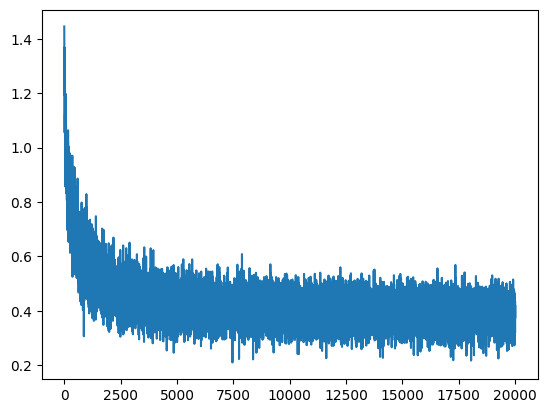

In [148]:
plt.plot(lossi)

(array([2147.,  224.,  130.,   88.,   57.,   44.,   43.,   37.,   28.,
          29.,   28.,   18.,   19.,   19.,    7.,   18.,   18.,   12.,
          19.,   21.,    8.,   18.,    4.,   12.,   16.,    8.,    9.,
          15.,   13.,   20.,   11.,   20.,   17.,   15.,   13.,   12.,
          16.,   20.,   20.,   28.,   30.,   37.,   38.,   45.,   38.,
          51.,   95.,  108.,  225., 2432.]),
 array([-1.  , -0.96, -0.92, -0.88, -0.84, -0.8 , -0.76, -0.72, -0.68,
        -0.64, -0.6 , -0.56, -0.52, -0.48, -0.44, -0.4 , -0.36, -0.32,
        -0.28, -0.24, -0.2 , -0.16, -0.12, -0.08, -0.04,  0.  ,  0.04,
         0.08,  0.12,  0.16,  0.2 ,  0.24,  0.28,  0.32,  0.36,  0.4 ,
         0.44,  0.48,  0.52,  0.56,  0.6 ,  0.64,  0.68,  0.72,  0.76,
         0.8 ,  0.84,  0.88,  0.92,  0.96,  1.  ]),
 <BarContainer object of 50 artists>)

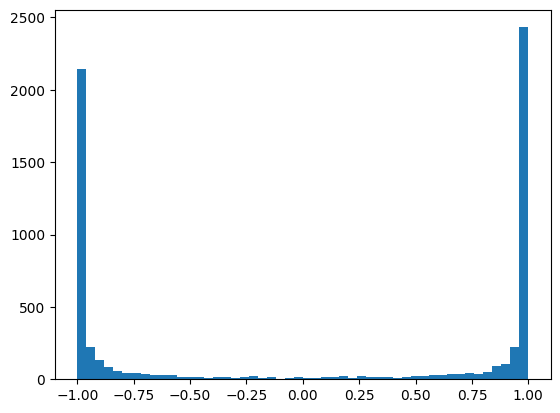

In [152]:
plt.hist(h.view(-1).tolist(),50)

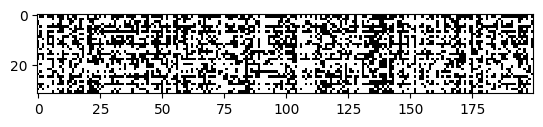

In [161]:
plt.imshow(h.abs() > 0.99, cmap="gray", interpolation="nearest")

In [157]:
# evaluation

@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0],-1)
    hpred = torch.tanh(embcat@W1 + b1)
    logits = hpred @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')


train 2.4837183952331543
val 2.5021183490753174


In [139]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize ...

    while True: # rull till '.' is predicted
        

        #forward pass the neural net
        emb = C[torch.tensor([context])] # 1 example, block size, e embed
        embcat = emb.view(emb.shape[0],-1) # emb.shape[0] should be 1?
        h = torch.tanh(embcat@W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()

        # shift the context window
        context = context[1:] + [ix]
        out.append(itos[ix])

        # if we get to '.', break
        if ix == 0:
            break
    print (''.join(out))

mona.
kmyah.
seel.
nihah.
marethruthndrae.
cadeero.
elin.
shy.
jenre.
elissopharleiyah.
hotelin.
shubergian.
jest.
jair.
jennox.
thana.
ubrence.
ryyah.
fael.
yuma.
